# Sistema de clasificación de imágenes

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

In [19]:
import os
import random
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf, keras
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report

### Carga del conjunto de datos

In [ ]:
# We explore the content
base_route = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats"

In [ ]:
def contar_jpg(route):
    return len([f for f in os.listdir(route) if f.lower().endswith('.jpg')]) if os.path.isdir(route) else 0

for root, dirs, files in os.walk(base_route):
    nivel = root.replace(base_route, '').count(os.sep)
    sangria = '  ' * nivel
    nombre_carpeta = os.path.basename(root)
    total_jpg = contar_jpg(root)
    print(f"{sangria}{nombre_carpeta}/ ({total_jpg} imágenes)")

data-dogs-cats/ (25000 imágenes)
  test/ (0 imágenes)
    dogs/ (12469 imágenes)
    cats/ (12468 imágenes)
  models/ (0 imágenes)
  train/ (0 imágenes)


    dogs/ (12500 imágenes)
    cats/ (12500 imágenes)


### Visualiza la información de entrada

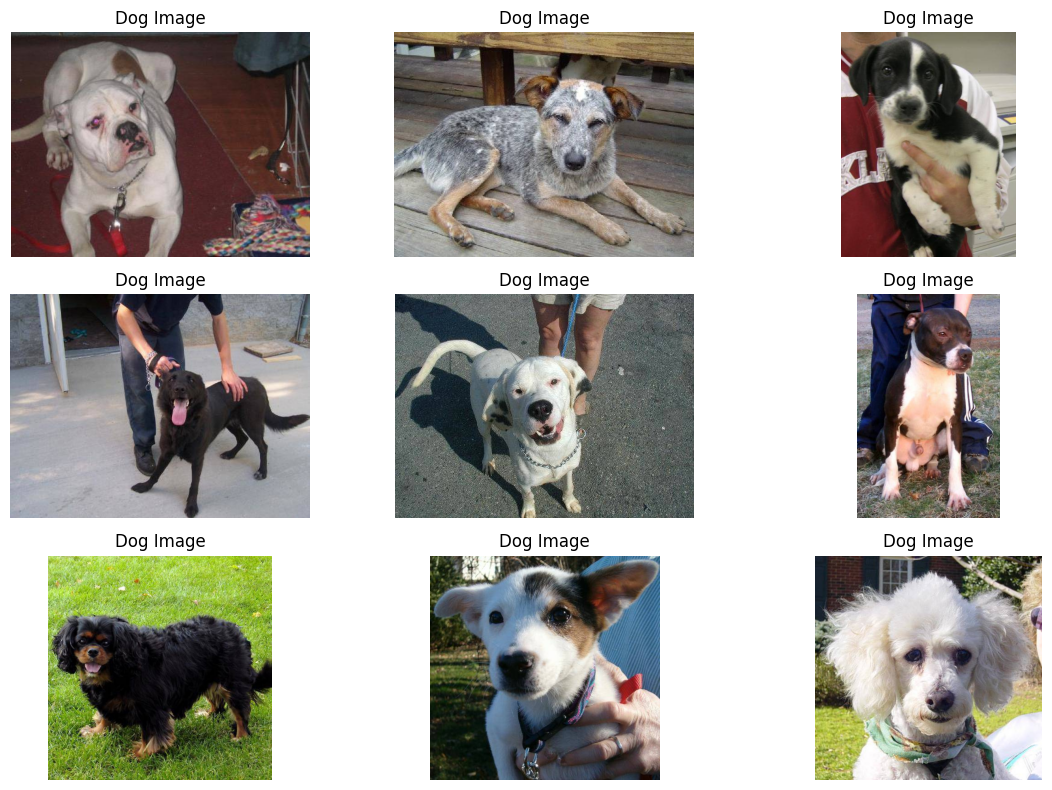

In [4]:
# Path to the directory containing your image data
data_dir = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/train"

# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir, "dogs")

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

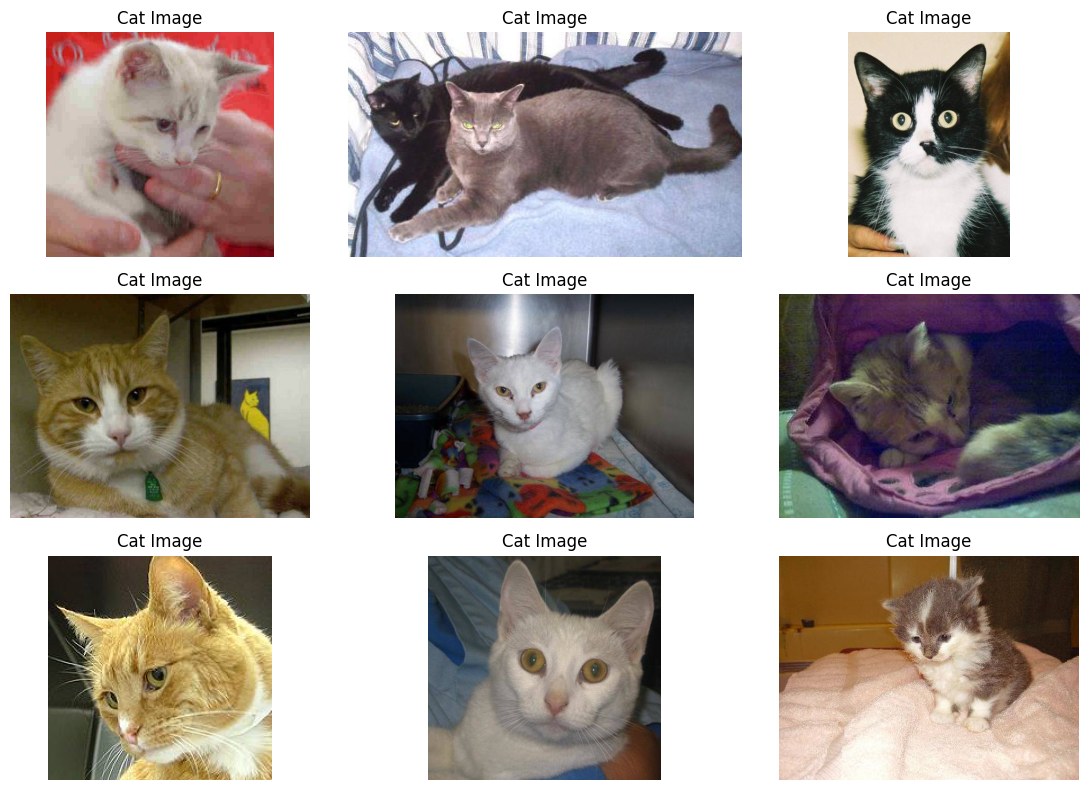

In [5]:
# Path to the directory containing your image data
data_dir = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/train"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir, "cats")

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

#### Observaciones:
Se visualizaron las primeras 9 imágenes de perros y gatos para inspeccionar el dataset.   
Se observó que las imágenes tienen distintos tamaños y posiciones del animal, por lo que se decidió redimensionarlas a un tamaño fijo antes del entrenamiento.

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 2

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Debug: confirma etiquetas binarias
xb, yb = next(train_data)
print("X:", xb.shape, "y:", yb.shape, "y sample:", yb[:10])

Found 25000 images belonging to 2 classes.
Found 24937 images belonging to 2 classes.
X: (2, 128, 128, 3) y: (2,) y sample: [0. 0.]


In [ ]:
model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    Conv2D(32, (3,3), padding="same", activation="relu"),
    Conv2D(32, (3,3), padding="same", activation="relu"),
    MaxPool2D(),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPool2D(),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    MaxPool2D(),

    Conv2D(256, (3,3), padding="same", activation="relu"),
    Conv2D(256, (3,3), padding="same", activation="relu"),
    MaxPool2D(),

    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

2026-02-23 21:18:24.951983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
# Compile the model before training using Adam 
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
checkpoint = ModelCheckpoint(
    "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [10]:
hist = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[checkpoint, early]
)

Epoch 1/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5539 - loss: 0.6782
Epoch 1: val_accuracy improved from None to 0.68890, saving model to /workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/best.keras
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 1777s 142ms/step - accuracy: 0.6021 - loss: 0.6569 - val_accuracy: 0.6889 - val_loss: 0.5944
Epoch 2/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6817 - loss: 0.5926
Epoch 2: val_accuracy improved from 0.68890 to 0.75045, saving model to /workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/best.keras
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 1650s 132ms/step - accuracy: 0.7024 - loss: 0.5733 - val_accuracy: 0.7505 - val_loss: 0.5156
Epoch 3/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7513 - loss: 0.5122
Epoch 3: val_accuracy improved from 0.75045 to 0.77932, saving model to /workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/best.keras
12500/12500 ━━━━━━━━━━━━━━

In [12]:
best_path = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/best.keras"
best_model = tf.keras.models.load_model(best_path)

In [13]:
test_loss, test_acc = best_model.evaluate(test_data, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

12469/12469 ━━━━━━━━━━━━━━━━━━━━ 391s 31ms/step - accuracy: 0.9354 - loss: 0.1671
Test loss: 0.1671 | Test acc: 0.9354


In [14]:
probs = best_model.predict(test_data, verbose=1)
preds = (probs.ravel() >= 0.5).astype(int)

true = test_data.classes
class_names = list(test_data.class_indices.keys())
print("class_indices:", test_data.class_indices)

12469/12469 ━━━━━━━━━━━━━━━━━━━━ 478s 38ms/step
class_indices: {'cats': 0, 'dogs': 1}


In [20]:
cm = confusion_matrix(true, preds)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(true, preds, target_names=class_names))

Confusion Matrix:
 [[11539   929]
 [  682 11787]]

Classification Report:
               precision    recall  f1-score   support

        cats       0.94      0.93      0.93     12468
        dogs       0.93      0.95      0.94     12469

    accuracy                           0.94     24937
   macro avg       0.94      0.94      0.94     24937
weighted avg       0.94      0.94      0.94     24937



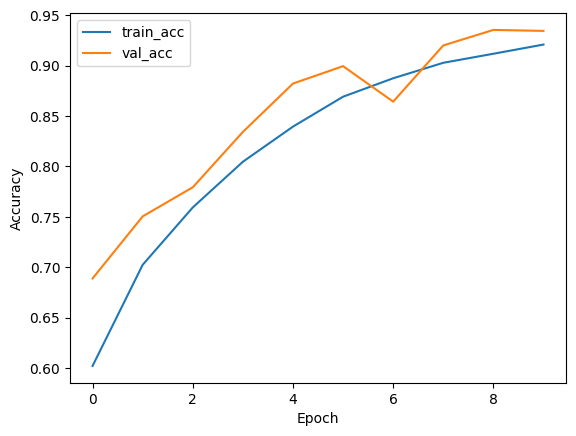

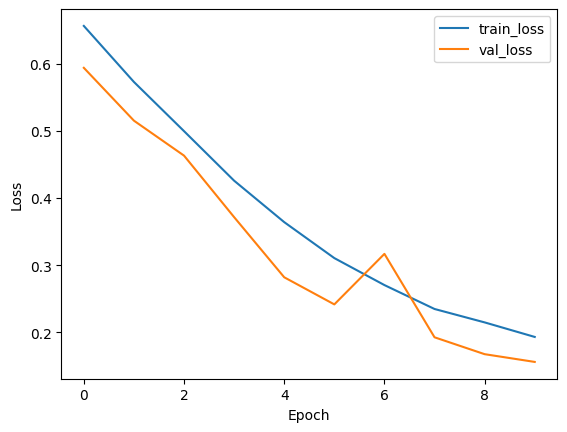

In [22]:
plt.figure()
plt.plot(hist.history["accuracy"], label="train_acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist.history["loss"], label="train_loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

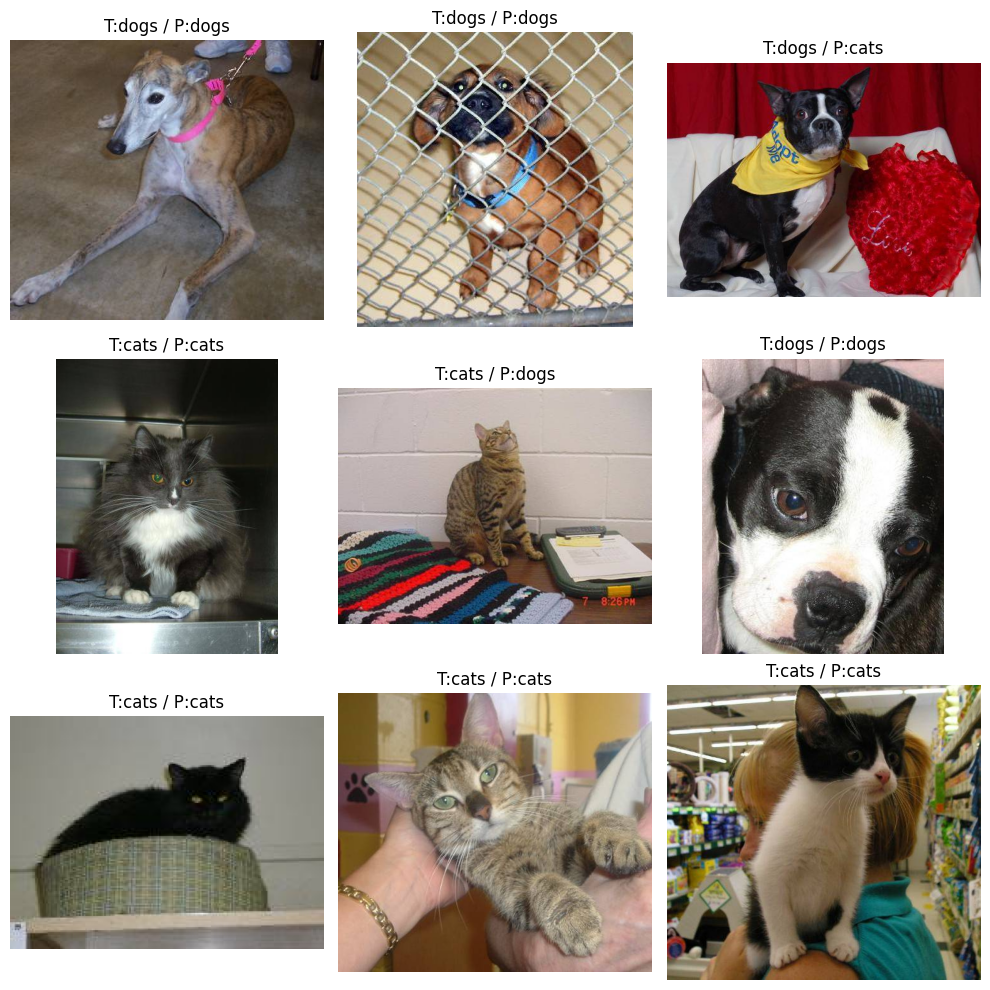

In [23]:
base_test_dir = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/test"

# 9 random files from the test
all_test_files = test_data.filenames
idxs = random.sample(range(len(all_test_files)), 9)

plt.figure(figsize=(10,10))
for i, idx in enumerate(idxs, 1):
    rel_path = all_test_files[idx]                   # e.g. 'cats/cat.123.jpg'
    img_path = os.path.join(base_test_dir, rel_path)

    img = mpimg.imread(img_path)
    pred_label = class_names[preds[idx]]
    true_label = class_names[true[idx]]

    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.title(f"T:{true_label} / P:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [24]:
final_path = "/workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/cats_dogs_final.keras"
best_model.save(final_path)
print("Modelo final guardado en:", final_path)

Modelo final guardado en: /workspaces/inetke-machine-learning/data/raw/data-dogs-cats/models/cats_dogs_final.keras
